# TTC Transit Service Reliability — Exploratory Data Analysis

Exploring what actually drives subway delays in the cleaned dataset, to
inform feature engineering for the prediction model and surface
findings for the dashboard / writeup.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

# Consistent palette used across every chart in this notebook
COLORS = {
    "primary": "#2E5C8A",     # steel blue — volume / counts
    "secondary": "#D97B29",   # burnt orange — averages / duration
    "accent": "#3D8F5E",      # green — positive/comparison highlight
    "muted": "#8A8A8A",       # grey — de-emphasized bars
    "warning": "#B23A3A",     # red — worst-case highlight
}
SEASON_COLORS = {"Winter": "#4A7FB5", "Spring": "#6FAE6E", "Summer": "#E0A63A", "Fall": "#B5652E"}

def annotate_bars(ax, fmt="{:,.0f}", **kwargs):
    """Add value labels above/beside bars for readability."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, fontsize=9, **kwargs)

conn = sqlite3.connect("../data/processed/ttc_reliability.db")
df = pd.read_sql("""
    SELECT f.*, s.station_name, d.day_of_week, d.is_weekend, d.season, c.code_description
    FROM fact_delay_events f
    LEFT JOIN dim_station s ON f.station_id = s.station_id
    LEFT JOIN dim_date d ON f.date_id = d.date_id
    LEFT JOIN dim_delay_code c ON f.code = c.code
""", conn, parse_dates=["date_id"])
conn.close()

df["code_description"] = df["code_description"].fillna("(no description available)")
print(f"{len(df):,} delay events loaded")
df.head()


23,701 delay events loaded


,date_id,time_of_day,hour,station_id,code,mode,bound,line,vehicle_id,min_delay,min_gap,station_name,day_of_week,is_weekend,season,code_description
0,2025-01-01,02:10,2,1,MUSAN,SUBWAY,E,BD,5227,5,9,BATHURST STATION,Wednesday,0,Winter,Unsanitary Vehicle
1,2025-01-01,07:59,7,2,TUNOA,SUBWAY,W,BD,5000,5,10,DONLANDS STATION,Wednesday,0,Winter,No Operator Immediately Available
2,2025-01-01,08:13,8,3,PUTR,SUBWAY,S,YU,5836,9,0,BLOOR STATION,Wednesday,0,Winter,Rail Related Problem
3,2025-01-01,08:15,8,3,PUTR,SUBWAY,N,YU,5706,5,0,BLOOR STATION,Wednesday,0,Winter,Rail Related Problem
4,2025-01-01,12:56,12,4,MUO,SUBWAY,S,YU,5706,4,8,VAUGHAN MC STATION,Wednesday,0,Winter,Miscellaneous Other


## 1. Delay volume by hour of day

Where station and hour showed up as the strongest predictors in the model — this is the raw pattern behind that.

      count  avg_delay_min
hour                      
0       720       8.330556
1       662       8.371601
2       100      10.090000
3        12       9.083333
4        16      41.250000
5       987      11.328267
6      1485       7.498990
7      1143       7.361330
8      1554       6.619691
9      1055       7.905213
10      953       6.971668
11     1016       8.111220
12      989       8.351871
13     1153       7.126626
14     1235       7.165992
15     1323       7.777022
16     1482       7.727395
17     1480       7.449324
18     1228       8.072476
19     1113       8.078167
20     1034       8.549323
21      992       7.425403
22     1054       8.199241
23      915       8.754098


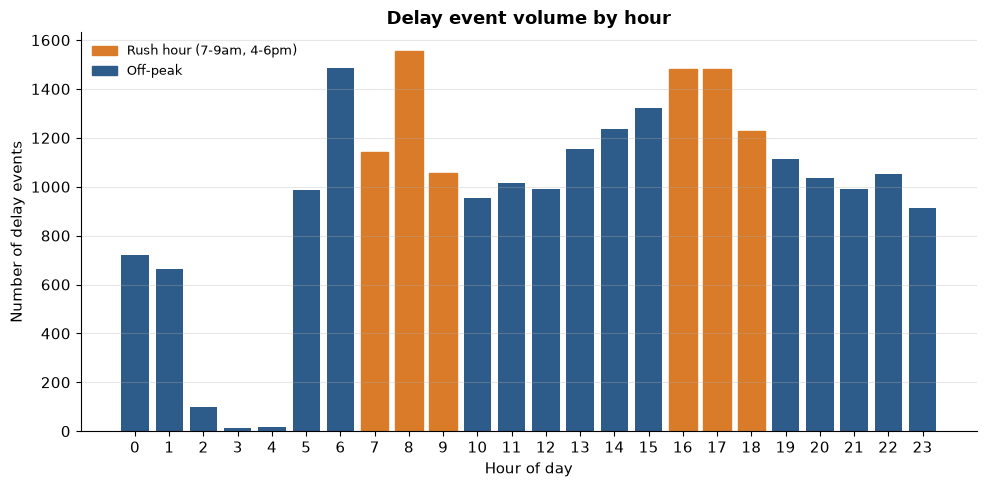

In [2]:
by_hour = df.groupby("hour")["min_delay"].agg(count="count", avg_delay_min="mean")
print(by_hour)

fig, ax = plt.subplots()
bars = ax.bar(by_hour.index, by_hour["count"], color=COLORS["primary"])
# Highlight rush-hour bars distinctly
rush_hours = {7, 8, 9, 16, 17, 18}
for hour, bar in zip(by_hour.index, bars):
    if hour in rush_hours:
        bar.set_color(COLORS["secondary"])
ax.set_ylabel("Number of delay events")
ax.set_xlabel("Hour of day")
ax.set_title("Delay event volume by hour", fontsize=13, fontweight="bold")
ax.set_xticks(range(0, 24))
ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color=COLORS["secondary"], label="Rush hour (7-9am, 4-6pm)"),
        plt.Rectangle((0,0),1,1, color=COLORS["primary"], label="Off-peak"),
    ],
    loc="upper left", frameon=False, fontsize=9,
)
plt.tight_layout()
plt.show()


## 2. Delay volume by day of week

             count  avg_delay_min
day_of_week                      
Monday        3528       8.003968
Tuesday       3734       7.607659
Wednesday     3674       7.455634
Thursday      3670       7.797275
Friday        3634       7.619703
Saturday      2911       7.529028
Sunday        2550       9.865098


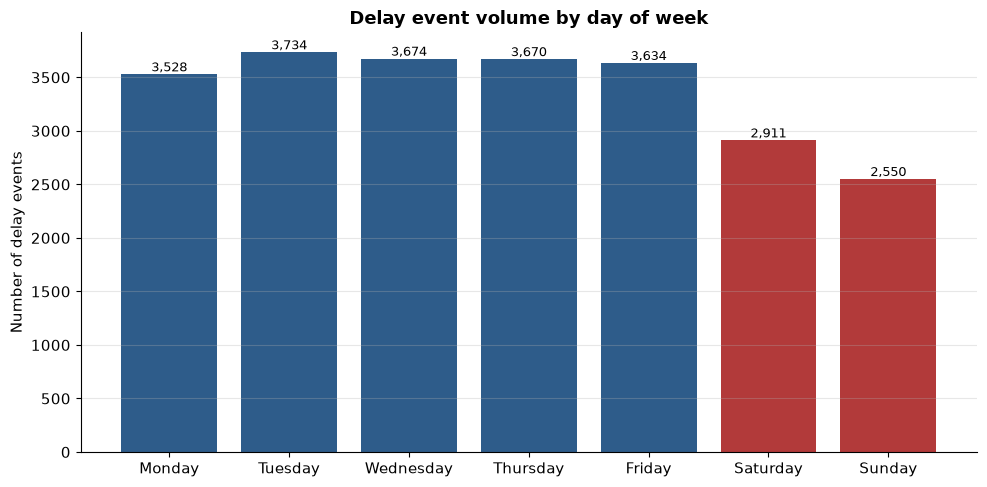

In [3]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_dow = df.groupby("day_of_week")["min_delay"].agg(count="count", avg_delay_min="mean").reindex(order)
print(by_dow)

fig, ax = plt.subplots()
colors = [COLORS["warning"] if d in ("Saturday","Sunday") else COLORS["primary"] for d in order]
bars = ax.bar(order, by_dow["count"], color=colors)
annotate_bars(ax)
ax.set_title("Delay event volume by day of week", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of delay events")
plt.tight_layout()
plt.show()


## 3. Top stations by delay volume

Top 15 stations — worth checking whether this just reflects ridership/train frequency (busier stations naturally log more delay events) rather than those stations being disproportionately *problematic*.

                       count  avg_delay_min
station_name                               
KIPLING STATION          857       6.250875
BLOOR STATION            811       5.977805
KENNEDY BD STATION       803       6.018680
EGLINTON STATION         733       8.095498
WILSON STATION           724       6.135359
FINCH STATION            722       6.378116
DAVISVILLE STATION       544       7.455882
YONGE BD STATION         483       7.188406
ST CLAIR STATION         458       6.799127
ST GEORGE YUS STATION    438       7.100457
COXWELL STATION          425       6.004706
LAWRENCE STATION         411       8.839416
UNION STATION            407       7.113022
WARDEN STATION           392       8.961735
VICTORIA PARK STATION    377      10.440318


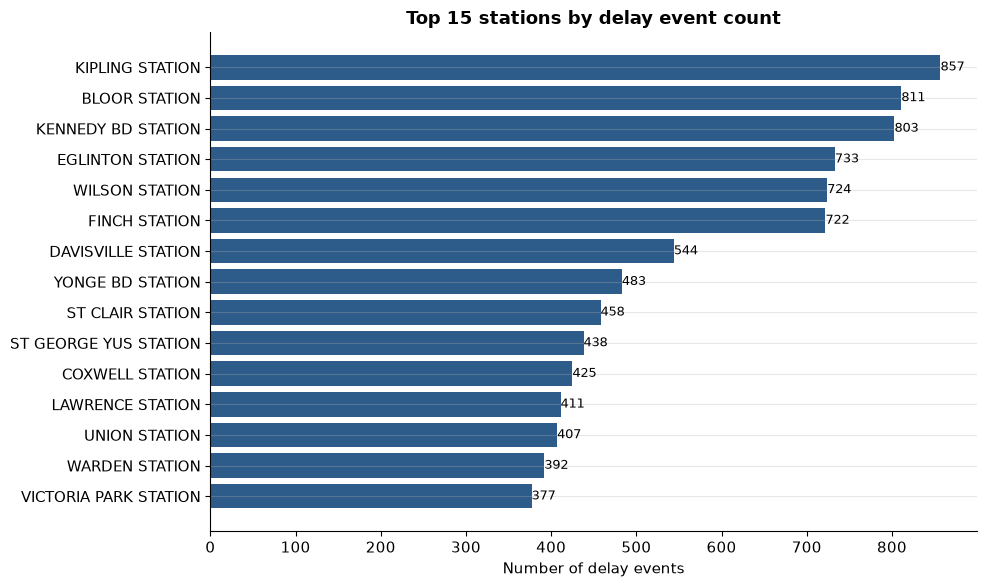

In [4]:
top_stations = (
    df.groupby("station_name")["min_delay"]
    .agg(count="count", avg_delay_min="mean")
    .sort_values("count", ascending=False)
    .head(15)
)
print(top_stations)

fig, ax = plt.subplots(figsize=(10, 6))
sorted_stations = top_stations.sort_values("count")
bars = ax.barh(sorted_stations.index, sorted_stations["count"], color=COLORS["primary"])
ax.set_title("Top 15 stations by delay event count", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of delay events")
annotate_bars(ax)
plt.tight_layout()
plt.show()


## 4. Top delay codes (root causes)

What's actually causing delays, in plain English — this is the piece that turns cryptic codes into a real root-cause story for the dashboard.

                                                          count  avg_delay_min
code  code_description                                                        
SUDP  Disorderly Patron                                    3020       6.569868
MUPAA Passenger Assistance Alarm Activated - No Troub...   2035       4.114005
PUOPO OPTO (COMMS) Train Door Monitoring                   1840       5.434783
MUIR  Injured or ill Customer (On Train) - Medical Ai...   1676       7.113962
SUO   Passenger Other                                      1278       9.207355
MUSAN Unsanitary Vehicle                                   1050       4.576190
SUUT  Unauthorized at Track Level                           886      12.932280
MUI   Injured or ill Customer (On Train) - Transported      873      11.335624
TUO   Transportation Department - Other                     784       5.877551
MUO   Miscellaneous Other                                   558       6.324373
MUDD  Door Problems - Debris Related                

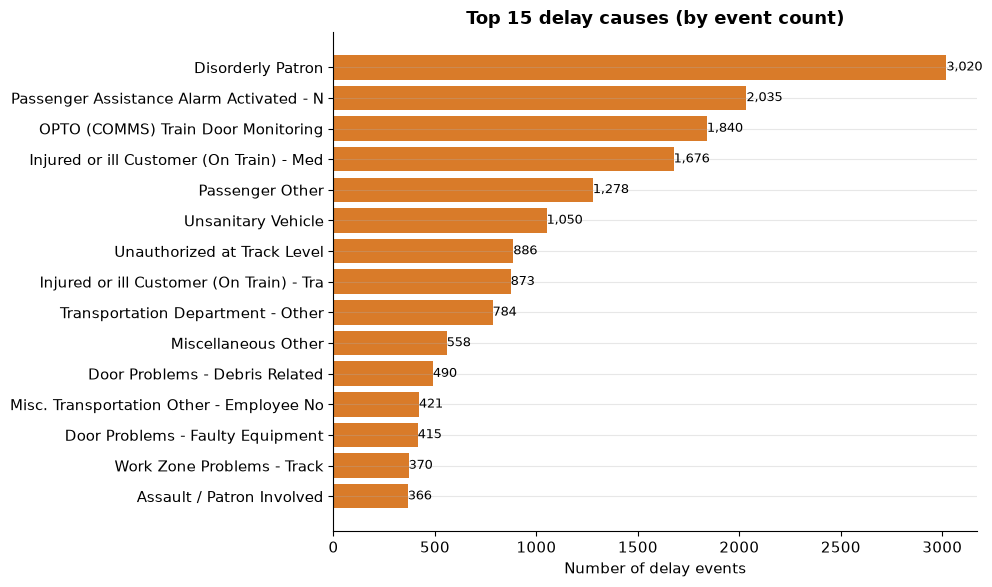

In [5]:
top_codes = (
    df.groupby(["code", "code_description"])["min_delay"]
    .agg(count="count", avg_delay_min="mean")
    .sort_values("count", ascending=False)
    .head(15)
)
print(top_codes)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{desc[:40]}" for _, desc in top_codes.index]
sorted_idx = top_codes["count"].values[::-1]
labels_sorted = labels[::-1]
bars = ax.barh(labels_sorted, sorted_idx, color=COLORS["secondary"])
ax.set_title("Top 15 delay causes (by event count)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of delay events")
annotate_bars(ax)
plt.tight_layout()
plt.show()


## 5. Delay volume by season

Checks whether winter (snow/cold) genuinely drives more delays — a natural motivator for pulling in weather data next.

        count  avg_delay_min
season                      
Winter   6756       8.675548
Spring   7329       7.798199
Summer   5134       7.490066
Fall     4482       7.406738


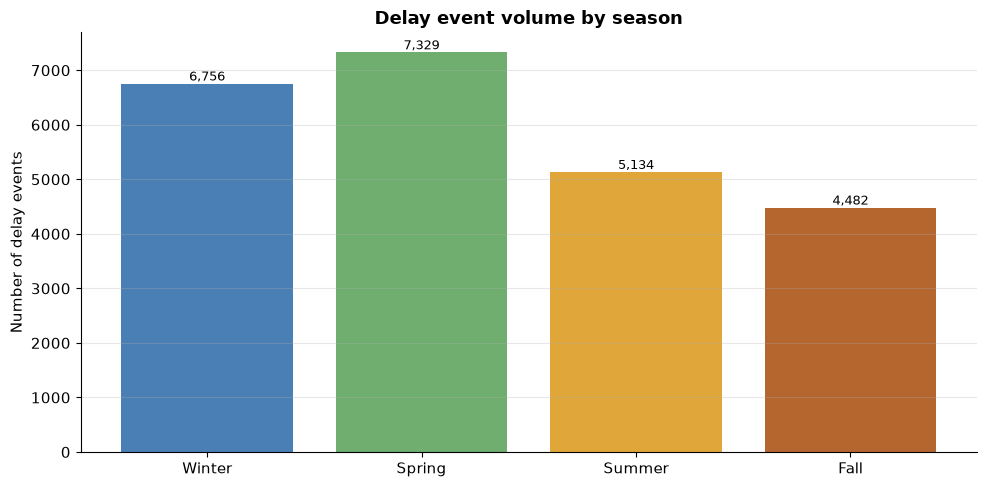

In [6]:
by_season = df.groupby("season")["min_delay"].agg(count="count", avg_delay_min="mean")
by_season = by_season.reindex(["Winter","Spring","Summer","Fall"])
print(by_season)

fig, ax = plt.subplots()
colors = [SEASON_COLORS[s] for s in by_season.index]
bars = ax.bar(by_season.index, by_season["count"], color=colors)
annotate_bars(ax)
ax.set_title("Delay event volume by season", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of delay events")
plt.tight_layout()
plt.show()


## 6. Distribution of delay length

How long delays actually run, not just how often they happen — a station with many *short* delays is a different problem than one with fewer but *longer* ones.

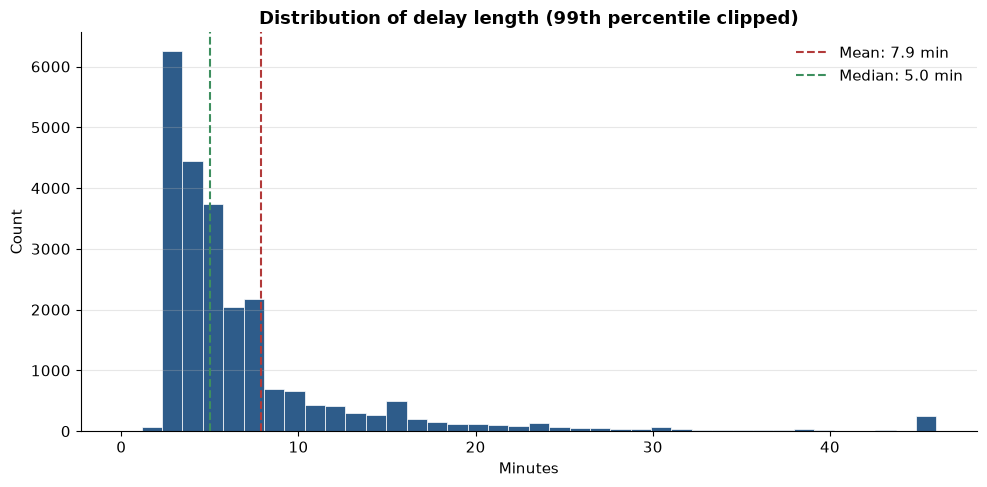

count    23701.000000
mean         7.907514
std         19.422430
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max        900.000000
Name: min_delay, dtype: float64

In [7]:
fig, ax = plt.subplots()
clipped = df["min_delay"].clip(upper=df["min_delay"].quantile(0.99))
ax.hist(clipped, bins=40, color=COLORS["primary"], edgecolor="white", linewidth=0.5)
mean_val, median_val = df["min_delay"].mean(), df["min_delay"].median()
ax.axvline(mean_val, color=COLORS["warning"], linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.1f} min")
ax.axvline(median_val, color=COLORS["accent"], linestyle="--", linewidth=1.5, label=f"Median: {median_val:.1f} min")
ax.set_title("Distribution of delay length (99th percentile clipped)", fontsize=13, fontweight="bold")
ax.set_xlabel("Minutes")
ax.set_ylabel("Count")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

df["min_delay"].describe()


## 7. Weekday vs weekend

Ties back into the model's feature importances, where `is_weekend` ranked low — sanity-check that against the raw pattern.

            count  avg_delay_min
is_weekend                      
Weekday     18240       7.694243
Weekend      5461       8.619850


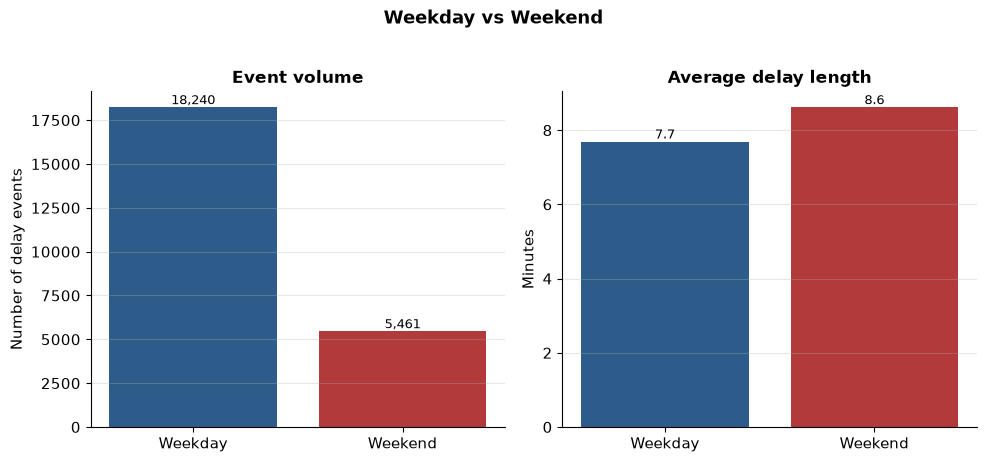

In [8]:
by_weekend = df.groupby("is_weekend")["min_delay"].agg(count="count", avg_delay_min="mean")
by_weekend.index = by_weekend.index.map({0: "Weekday", 1: "Weekend"})
print(by_weekend)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(by_weekend.index, by_weekend["count"], color=[COLORS["primary"], COLORS["warning"]])
axes[0].set_title("Event volume", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of delay events")
annotate_bars(axes[0])

axes[1].bar(by_weekend.index, by_weekend["avg_delay_min"], color=[COLORS["primary"], COLORS["warning"]])
axes[1].set_title("Average delay length", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Minutes")
annotate_bars(axes[1], fmt="{:.1f}")

plt.suptitle("Weekday vs Weekend", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 8. Model comparison — Random Forest vs Gradient Boosting

The baseline model in `ttc_pipeline.py` uses Gradient Boosting, selected after
comparing it against Random Forest on the same feature set. Rebuilding both
here for a direct side-by-side.

Random Forest ROC-AUC:     0.635
Gradient Boosting ROC-AUC: 0.644


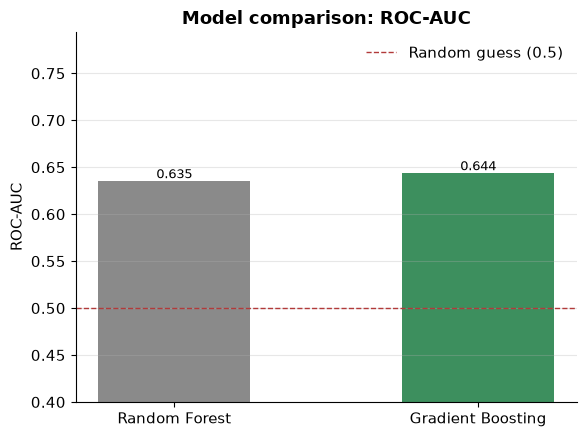

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

df["target"] = (df["min_delay"] >= 5).astype(int)
cat_cols = ["hour", "day_of_week", "season", "station_name", "line", "bound", "mode"]
model_df = df.dropna(subset=cat_cols)

X = pd.DataFrame(index=model_df.index)
for c in cat_cols:
    X[c] = LabelEncoder().fit_transform(model_df[c].astype(str))
X["is_weekend"] = model_df["is_weekend"].astype(int)
X["is_rush_hour"] = model_df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
y = model_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
)
gb.fit(X_train, y_train)
gb_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])

print(f"Random Forest ROC-AUC:     {rf_auc:.3f}")
print(f"Gradient Boosting ROC-AUC: {gb_auc:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
models = ["Random Forest", "Gradient Boosting"]
scores = [rf_auc, gb_auc]
bars = ax.bar(models, scores, color=[COLORS["muted"], COLORS["accent"]], width=0.5)
ax.axhline(0.5, color=COLORS["warning"], linestyle="--", linewidth=1, label="Random guess (0.5)")
ax.set_ylim(0.4, max(scores) + 0.15)
ax.set_ylabel("ROC-AUC")
ax.set_title("Model comparison: ROC-AUC", fontsize=13, fontweight="bold")
annotate_bars(ax, fmt="{:.3f}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Reading the comparison:** if the two AUC scores land close together (within
~0.01-0.02), that's a signal the *features* — not the model family — are the
real ceiling right now. That would point toward richer features (weather,
rush-hour flag, rolling delay frequency per station) as the higher-leverage
next step, rather than trying more model types.

## 9. Feature importances (Gradient Boosting)

What the model is actually leaning on to make predictions — this is the
piece that tells you which findings above are actually *usable* by a model,
versus just visually interesting.

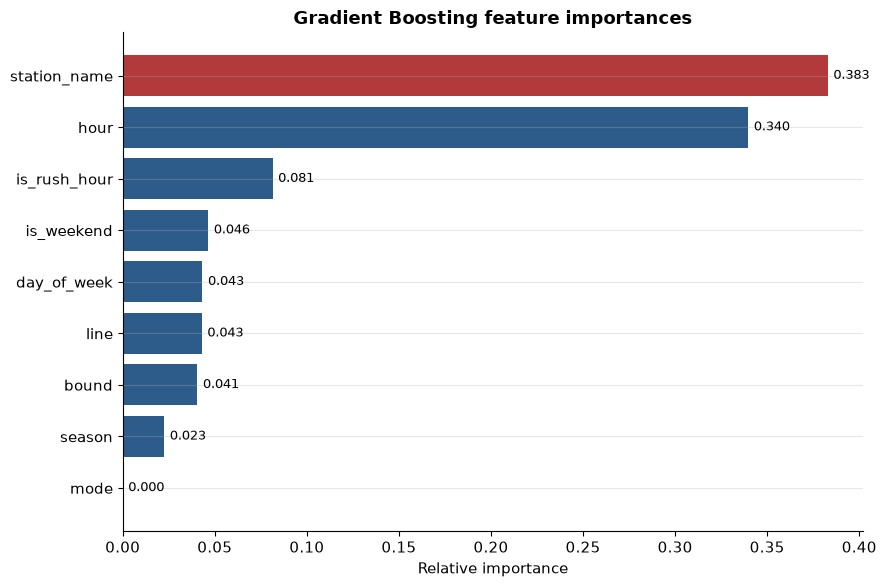

In [10]:
importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [COLORS["warning"] if v == importances.max() else COLORS["primary"] for v in importances]
ax.barh(importances.index, importances.values, color=colors)
ax.set_title("Gradient Boosting feature importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Relative importance")
for i, v in enumerate(importances.values):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 10. Rolling 30-day delay frequency — top station over time

Rather than a single station-level average, this shows how delay frequency
at the single busiest station moves over time — surfacing whether "bad
stretches" are a real, visible pattern rather than just noise.

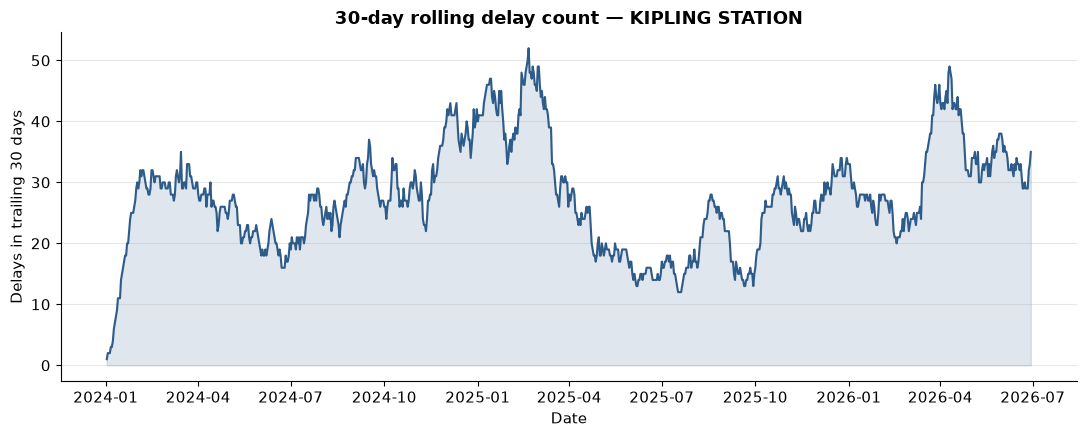

In [11]:
top_station_name = df["station_name"].value_counts().idxmax()
station_df = df[df["station_name"] == top_station_name].copy()
station_df["date_only"] = pd.to_datetime(station_df["date_id"]).dt.normalize()

daily_counts = station_df.groupby("date_only").size().rename("daily_count")
full_range = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq="D")
daily_counts = daily_counts.reindex(full_range, fill_value=0)
rolling_30d = daily_counts.rolling(window=30, min_periods=1).sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(rolling_30d.index, rolling_30d.values, color=COLORS["primary"], linewidth=1.5)
ax.fill_between(rolling_30d.index, rolling_30d.values, color=COLORS["primary"], alpha=0.15)
ax.set_title(f"30-day rolling delay count — {top_station_name}", fontsize=13, fontweight="bold")
ax.set_ylabel("Delays in trailing 30 days")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()


## Findings summary

- **Peak delay hours:** Volume peaks at rush hour (8am, 4-5pm) as expected, but the *longest* individual delays happen overnight (4-5am) — rare but severe, vs. rush hour's frequent-but-short pattern.
- **Day of week:** Sunday has the fewest delay events but by far the highest average delay length (~9.9 min vs. ~7.5-8 min on weekdays) — reduced Sunday service likely means less redundancy when something does go wrong.
- **Worst stations:** Kipling, Bloor, and Kennedy BD lead in raw delay count, but that's likely conflated with being major interchange/terminal stations with heavier train traffic. Victoria Park is the more meaningful signal — lower volume but the highest average delay length (~10.4 min) of the top 15.
- **Top root causes:** The top 3 delay codes (Disorderly Patron, Passenger Assistance Alarm, Door Monitoring) are all passenger/human-behavior related, not mechanical failure — no amount of new equipment fixes the #1 cause.
- **Seasonal pattern:** Winter has both the most delay events and the longest average delays of any season — motivated pulling in weather data.
- **Model ceiling:** Across Random Forest, Gradient Boosting, weather features, a rush-hour flag, and rolling per-station delay frequency, ROC-AUC consistently lands around 0.62-0.65. `hour` and `station` dominate every feature-importance ranking — this class of feature (schedule/location/weather) has hit a real ceiling; further gains would likely need a different data source (live vehicle positions, ridership counts) rather than more derived features from the delay log itself.
